In [9]:
import os
import glob
import matplotlib.pyplot as plt
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

## Set up PySpark Session

In [10]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

## Directories

In [11]:
bronze_lms_directory = "datalake/bronze/lms/"
bronze_fin_directory = "datalake/bronze/financial/"
bronze_attr_directory = "datalake/bronze/attributes/"
bronze_click_directory = "datalake/bronze/clickstream/"

# LMS EDA

In [12]:
# Load all bronze LMS CSVs at once and process
all_lms_files = glob.glob(os.path.join(bronze_lms_directory, '*.csv'))
df = spark.read.csv(all_lms_files, header=True, inferSchema=True)
print(f"loaded {len(all_lms_files)} files, total row count: {df.count()}")

column_type_map = {
    "loan_id": StringType(),
    "Customer_ID": StringType(),
    "loan_start_date": DateType(),
    "tenure": IntegerType(),
    "installment_num": IntegerType(),
    "loan_amt": FloatType(),
    "due_amt": FloatType(),
    "paid_amt": FloatType(),
    "overdue_amt": FloatType(),
    "balance": FloatType(),
    "snapshot_date": DateType(),
}
for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

loaded 24 files, total row count: 104288


### Distributions & Summary Statistics

Shape: 104288 rows x 11 columns

Schema:
root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: float (nullable = true)
 |-- due_amt: float (nullable = true)
 |-- paid_amt: float (nullable = true)
 |-- overdue_amt: float (nullable = true)
 |-- balance: float (nullable = true)
 |-- snapshot_date: date (nullable = true)

Missing (null or empty) per column:
                 null_or_empty
loan_id                      0
Customer_ID                  0
loan_start_date              0
tenure                       0
installment_num              0
loan_amt                     0
due_amt                      0
paid_amt                     0
overdue_amt                  0
balance                      0
snapshot_date                0 

Distinct values per column:
                 distinct
loan_id             11974
Customer_I

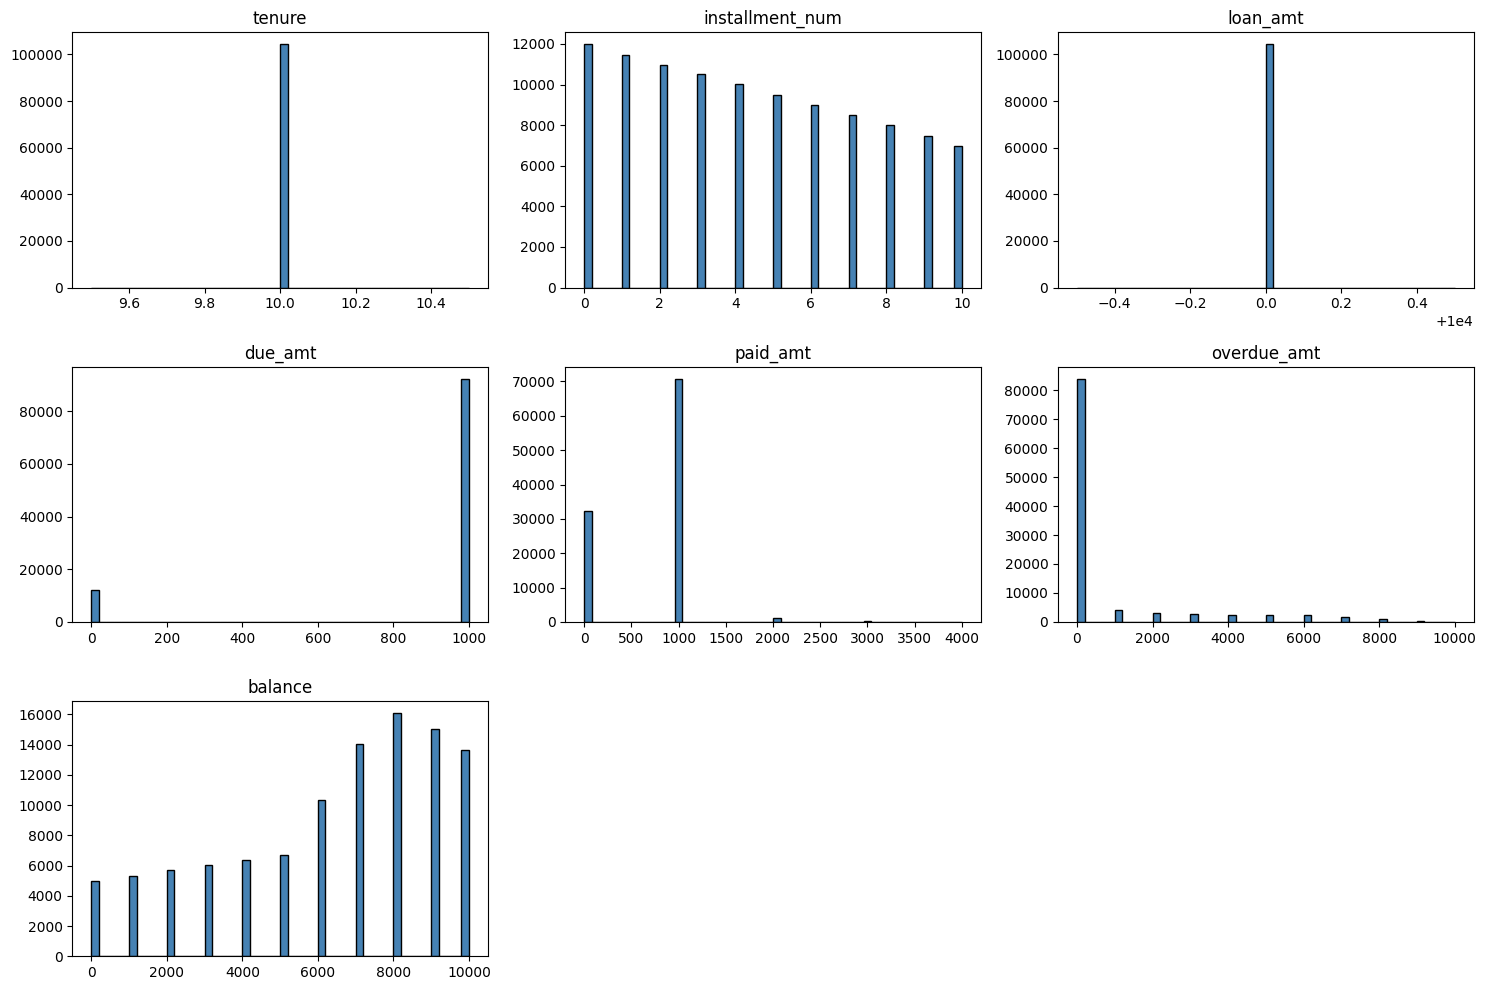

In [13]:
# Basic EDA: LMS table
lms_df = df
print(f"Shape: {lms_df.count()} rows x {len(lms_df.columns)} columns")

print("\nSchema:")
lms_df.printSchema()

# Missing values (null or empty string) per column
miss = lms_df.select([
    F.sum(F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), 1).otherwise(0)).alias(c)
    for c in lms_df.columns
]).toPandas().T.rename(columns={0: "null_or_empty"})
print("Missing (null or empty) per column:")
print(miss, "\n")

# Distinct values per column
dist = lms_df.select([
    F.countDistinct(F.col(c)).alias(c) for c in lms_df.columns
]).toPandas().T.rename(columns={0: "distinct"})
print("Distinct values per column:")
print(dist, "\n")

# Date coverage
lms_df.select(
    F.min("loan_start_date").alias("loan_start_min"),
    F.max("loan_start_date").alias("loan_start_max"),
    F.min("snapshot_date").alias("snapshot_min"),
    F.max("snapshot_date").alias("snapshot_max"),
).show()

# Numeric columns: summary statistics + distributions
num_cols = ["tenure", "installment_num", "loan_amt", "due_amt",
            "paid_amt", "overdue_amt", "balance"]
lms_pdf = lms_df.select(num_cols).toPandas()
print("Numeric summary statistics:")
print(lms_pdf.describe().T, "\n")

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, c in zip(axes, num_cols):
    ax.hist(lms_pdf[c].dropna(), bins=50, color="steelblue", edgecolor="black")
    ax.set_title(c)
for ax in axes[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
df.toPandas()

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-09-01
1,CUS_0x1011_2023_11_01,CUS_0x1011,2023-11-01,10,10,10000.0,1000.0,1000.0,0.0,0.0,2024-09-01
2,CUS_0x1013_2023_12_01,CUS_0x1013,2023-12-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-09-01
3,CUS_0x1018_2023_11_01,CUS_0x1018,2023-11-01,10,10,10000.0,1000.0,0.0,7000.0,7000.0,2024-09-01
4,CUS_0x102d_2024_01_01,CUS_0x102d,2024-01-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-09-01
...,...,...,...,...,...,...,...,...,...,...,...
104283,CUS_0xe98_2023_01_01,CUS_0xe98,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01
104284,CUS_0xea6_2023_01_01,CUS_0xea6,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01
104285,CUS_0xed3_2023_01_01,CUS_0xed3,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01
104286,CUS_0xed8_2023_01_01,CUS_0xed8,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01


## EDA on credit labels (gold loans)

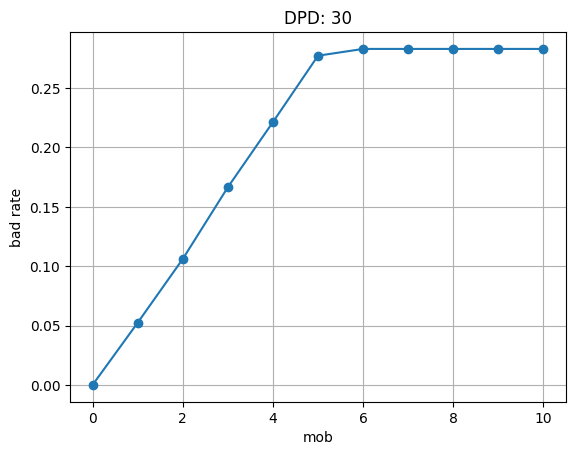

In [15]:
from datetime import datetime

# set dpd label definition
dpd = 30

# Path to the folder containing silver loan parquet files
silver_loan_daily_directory = "datalake/silver/lms_loan_daily/"
folder_path = silver_loan_daily_directory

# Read all parquet files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# derive mob, installments_missed, first_missed_date, dpd (project silver doesn't carry them)
df = df.withColumn("mob", col("installment_num").cast(IntegerType()))
df = df.withColumn("installments_missed", F.ceil(col("overdue_amt") / col("due_amt")).cast(IntegerType())).fillna(0)
df = df.withColumn("first_missed_date", F.when(col("installments_missed") > 0, F.add_months(col("snapshot_date"), -1 * col("installments_missed"))).cast(DateType()))
df = df.withColumn("dpd", F.when(col("overdue_amt") > 0.0, F.datediff(col("snapshot_date"), col("first_missed_date"))).otherwise(0).cast(IntegerType()))

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()